In [10]:
from xgboost import XGBRegressor
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

In [2]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    random_state=42,
    n_jobs=-1,
    eval_metric=["rmse", "mae"],
    early_stopping_rounds=100,
)


In [3]:
# Copy data
df = pd.read_csv("cleaned_data.csv")

# Compute max_progress per Opportunity
max_progress_per_opportunity = df.groupby('Opportunity')['Progress'].max()
df['max_progress'] = df['Opportunity'].map(max_progress_per_opportunity)


In [4]:
# Normalize Progress to 0-1
df['Progress_normalized'] = (df['Progress'] - 1) / (df['max_progress'] - 1)
df['Progress_normalized'] = df['Progress_normalized'].fillna(0)  # handle max_progress = 1

In [5]:
categorical_cols = ['Industry', 'Company', 'Gender', 'Race', 'Institution', 'Qualification']
label_encoders = {}

for col in categorical_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col + '_encoded'] = le.fit_transform(df[col])
        label_encoders[col] = le

In [6]:
# Select features
feature_columns = ['Age', 'Aggregate', 'NumCandidates'] + [col + '_encoded' for col in categorical_cols if col in df.columns]
discipline_cols = [col for col in df.columns if col.startswith('Discipline_')]
feature_columns.extend(discipline_cols)

# Prepare X and y
X = df[feature_columns]
y = df['Progress_normalized']

In [7]:
# Stratify by rounded normalized progress
y_strat = np.round(df['Progress_normalized'] * 10)
X_train, X_validation, y_train, y_validation = train_test_split(
    X, df['Progress_normalized'], test_size=0.2, random_state=42, stratify=y_strat
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_validation.shape[0]}")

Training set size: 64425
Validation set size: 16107


In [8]:
# Uses your previously defined X_train, y_train, X_validation, y_validation
xgb.fit(
    X_train, y_train,
    eval_set=[(X_validation, y_validation)],
    verbose=False
)

best_iter = getattr(xgb, "best_iteration", None)
print(f"Best iteration: {best_iter + 1 if best_iter is not None else 'n/a'}")


Best iteration: 911


In [12]:
model = xgb

y_train_pred = np.clip(model.predict(X_train), 0, 1)
y_val_pred = np.clip(model.predict(X_validation), 0, 1)

In [13]:
train_mse = mean_squared_error(y_train, y_train_pred)
val_mse = mean_squared_error(y_validation, y_val_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
val_mae = mean_absolute_error(y_validation, y_val_pred)
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_validation, y_val_pred)

print("\n" + "="*40)
print("MODEL PERFORMANCE")
print("="*40)
print(f"Training   - MSE: {train_mse:.4f}, MAE: {train_mae:.4f}, R²: {train_r2:.4f}")
print(f"Validation - MSE: {val_mse:.4f}, MAE: {val_mae:.4f}, R²: {val_r2:.4f}")


MODEL PERFORMANCE
Training   - MSE: 0.0203, MAE: 0.0811, R²: 0.5500
Validation - MSE: 0.0281, MAE: 0.0946, R²: 0.3757


In [16]:
# Get feature importances from the trained XGBoost model
importances = model.feature_importances_

# Create DataFrame sorted by absolute importance
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))



Top 10 Most Important Features:
                           Feature  Importance
                  Industry_encoded    0.200948
                    Discipline_Law    0.159262
                   Company_encoded    0.085037
                     NumCandidates    0.065213
                      Race_encoded    0.040007
                    Gender_encoded    0.035910
               Institution_encoded    0.030963
                  Discipline_Other    0.030956
              Discipline_Marketing    0.027516
Discipline_Accounting and Auditing    0.026857


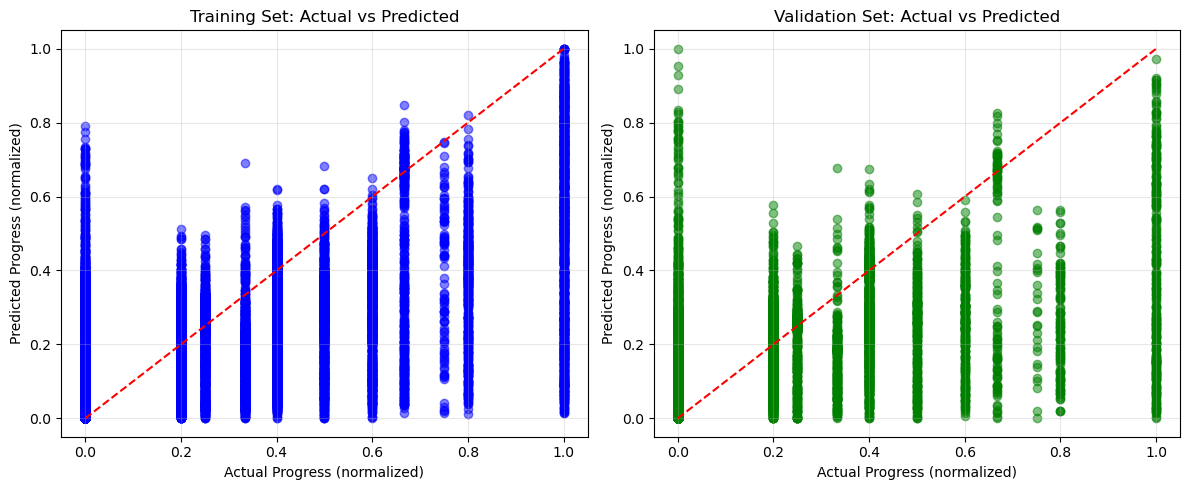

In [17]:
# Scatter plot: Actual vs Predicted
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Training set
ax1.scatter(y_train, y_train_pred, alpha=0.5, color='blue')
ax1.plot([0, 1], [0, 1], 'r--')  # 45-degree line (perfect predictions)
ax1.set_title("Training Set: Actual vs Predicted")
ax1.set_xlabel("Actual Progress (normalized)")
ax1.set_ylabel("Predicted Progress (normalized)")
ax1.grid(True, alpha=0.3)

# Validation set
ax2.scatter(y_validation, y_val_pred, alpha=0.5, color='green')
ax2.plot([0, 1], [0, 1], 'r--')
ax2.set_title("Validation Set: Actual vs Predicted")
ax2.set_xlabel("Actual Progress (normalized)")
ax2.set_ylabel("Predicted Progress (normalized)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

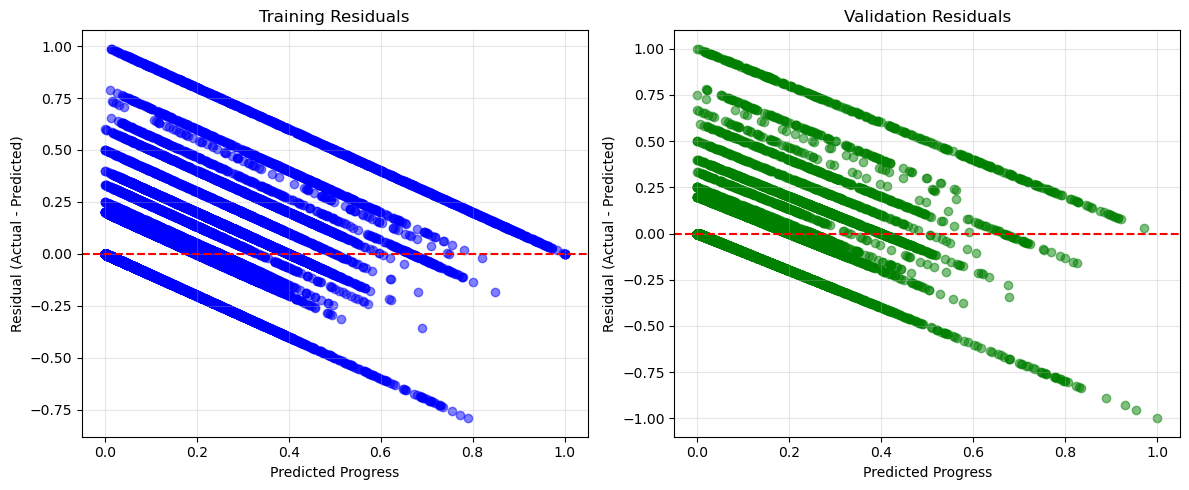

In [18]:
# Residual plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Training residuals
train_resid = y_train - y_train_pred
ax1.scatter(y_train_pred, train_resid, alpha=0.5, color='blue')
ax1.axhline(0, color='r', linestyle='--')
ax1.set_title("Training Residuals")
ax1.set_xlabel("Predicted Progress")
ax1.set_ylabel("Residual (Actual - Predicted)")
ax1.grid(True, alpha=0.3)

# Validation residuals
val_resid = y_validation - y_val_pred
ax2.scatter(y_val_pred, val_resid, alpha=0.5, color='green')
ax2.axhline(0, color='r', linestyle='--')
ax2.set_title("Validation Residuals")
ax2.set_xlabel("Predicted Progress")
ax2.set_ylabel("Residual (Actual - Predicted)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


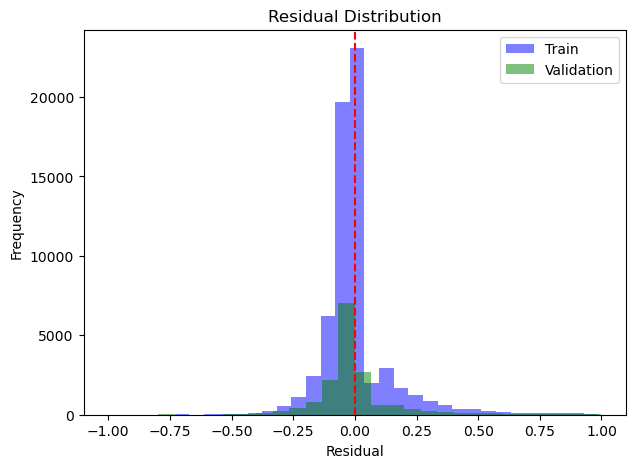

In [ ]:
# Histogram of residuals
plt.figure(figsize=(7,5))
plt.hist(train_resid, bins=30, alpha=0.5, label="Train", color="blue")
plt.hist(val_resid, bins=30, alpha=0.5, label="Validation", color="green")
plt.axvline(0, color="red", linestyle="--")
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.legend()
plt.show()


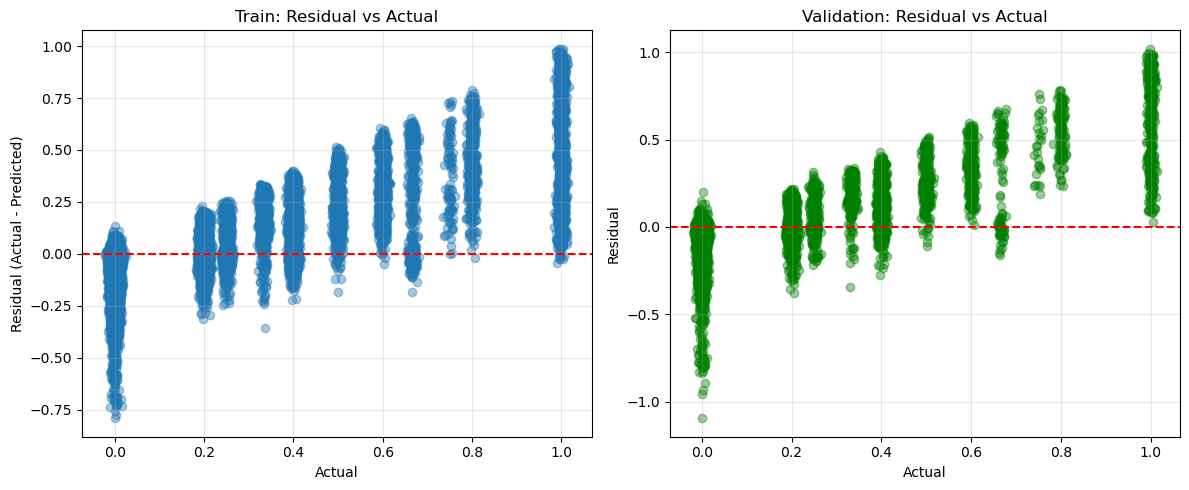

In [24]:
# Predictions WITHOUT clipping
y_train_pred_raw = model.predict(X_train)
y_val_pred_raw   = model.predict(X_validation)

# Residuals
train_resid = y_train - y_train_pred_raw
val_resid   = y_validation - y_val_pred_raw

# Residual vs Actual (add jitter to actual to reduce striping visual)
rng = np.random.default_rng(42)
jit_train = y_train + rng.normal(0, 0.005, size=len(y_train))
jit_val   = y_validation + rng.normal(0, 0.005, size=len(y_validation))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(jit_train, train_resid, alpha=0.4)
ax1.axhline(0, color='r', ls='--'); ax1.set_title("Train: Residual vs Actual")
ax1.set_xlabel("Actual"); ax1.set_ylabel("Residual (Actual - Predicted)"); ax1.grid(alpha=0.3)

ax2.scatter(jit_val, val_resid, alpha=0.4, color='green')
ax2.axhline(0, color='r', ls='--'); ax2.set_title("Validation: Residual vs Actual")
ax2.set_xlabel("Actual"); ax2.set_ylabel("Residual"); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()
